# Statistic for AI and Data Science Coursework 2 - Samuel Edwards 

# Texas Bridge Data Regression Modeling Review

## Contents

1. Introduction
2. Data Preparation 
3. Exploratory Analysis
4. Regression Modeling
5. Conclusion

## 1. Introduction

This report presents an analysis of the Texas Bridge dataset for the Texas Department of Transportation. Our primary goal is to investigate using linear regression to predict the condition of bridges based on the data we have with regards to their age, average daily use, percentage of trucks using the bridge, bridge design and bridge material. From this we will ascertain which of the proposed predictor variables has more influence on the current condition, and how well each of the proposed predictor variables predict the bridge condition.

## 2. Data Preparation

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_rows', 500) 
pd.set_option('display.max_columns', None) 

In [2]:
types_dict = { 'Structure_id': str, 'District':'category', 'Toll':'category', 
              'Maintainer':'category', 'Urban':'category', 'Status':'category', 
              'Historic':'category', 'Service_under':'category', 'Material':'category', 
              'Design':'category', 'Deck_rating':'category', 'Superstr_rating':'category', 
              'Substr_rating':'category', 'Scour_rating':'category'}

bridges = pd.read_csv('tx19_bridges_sample.csv', dtype=types_dict, index_col='Structure_id')

rating_dict = {'Failed': 0, 'Failing': 1, 'Critical': 2, 'Serious': 3, 
                 'Poor': 4, 'Fair': 5, 'Satisfactory': 6, 'Good': 7,
                'Very Good': 8, 'Excellent': 9}

print(len(bridges))
bridges = bridges.dropna()

def replace_condition(condition):
    return rating_dict[condition]

bridges['Deck_Rating'] = bridges['Deck_rating'].apply(replace_condition).astype('int64')
bridges['Superstr_Rating'] = bridges['Superstr_rating'].apply(replace_condition).astype('int64')
bridges['Substr_Rating'] = bridges['Substr_rating'].apply(replace_condition).astype('int64')
bridges['Current_Condition'] = bridges['Deck_Rating'] + bridges['Superstr_Rating'] + bridges['Substr_Rating']
bridges['Age'] = date.today().year - bridges['Year']


34293


The data cleaning process began with dropping NaNs and formulating a current condition score. There are only 7 entries containing NaNs out of over 34,000, due to this being a negligible amount they have been dropped.

To acquire quantifiable condition figures, the ‘Failed-Excellent’ ratings in the columns Deck_Ratings, Superstr_Rating and Substr_Rating have been mapped to numerical ratings ranging from 0 to 9. The sum has been taken from these three ratings to give an overall Current_Condition score ranging from 0 to 27.

Although the Current_Condition variable is technically ordinal, it has been treated as continuous for the linear regression model. This is due to the high number of score categories allowing for a reasonable regression model to be fit for analysis.

In [3]:
def bin_current_con(row):
    if row < 15:
        return 'Poor/Failing'
    elif row < 20: 
        return 'Fair'
    elif row < 24:
        return 'Good'
    else: 
        return 'Excellent'
    
bridges['Current_Condition_Category'] = bridges['Current_Condition'].apply(bin_current_con)

condition_order = ['Poor/Failing', 'Fair', 'Good', 'Excellent']

bridges['Current_Condition_Category'] = pd.Categorical(bridges['Current_Condition_Category'], categories=condition_order, ordered=True)

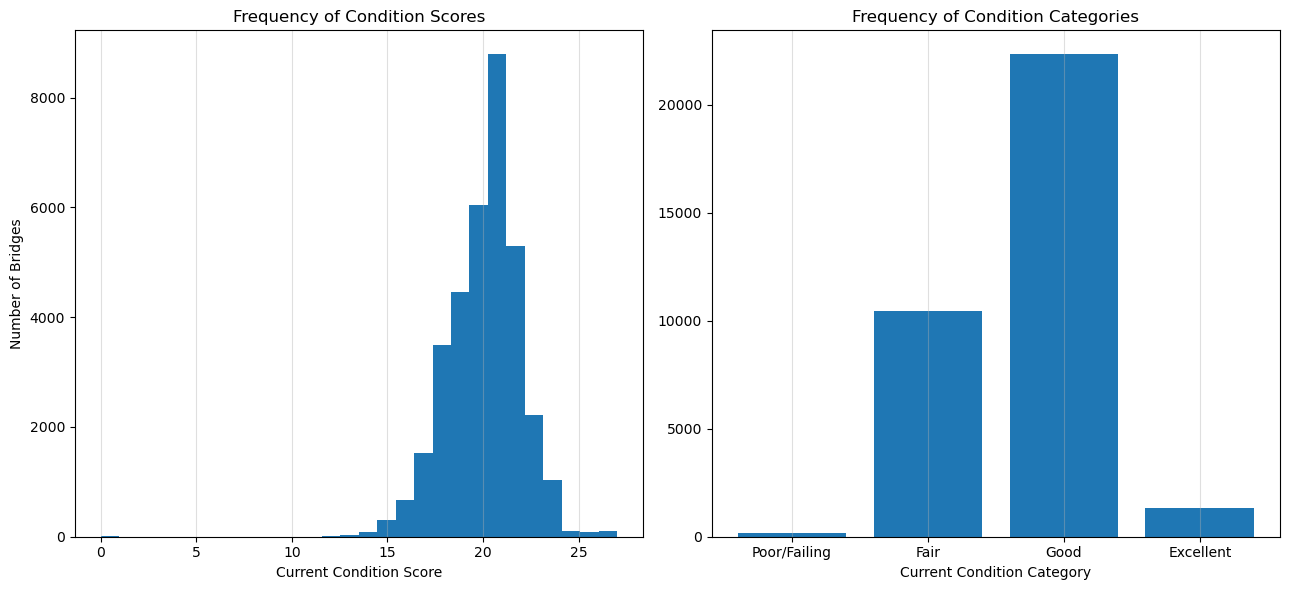

In [4]:
fig, axes = plt.subplots(nrows = 1, ncols= 2, figsize=(13,6))

axes[0].hist(bridges['Current_Condition'], bins=28)
axes[0].set_title('Frequency of Condition Scores')
axes[0].set_ylabel('Number of Bridges')
axes[0].set_xlabel('Current Condition Score')
axes[0].grid(axis='x', alpha=0.4)

condition_counts = bridges['Current_Condition_Category'].value_counts().sort_index()

axes[1].bar(condition_counts.index, condition_counts.values)
axes[1].set_title('Frequency of Condition Categories')
axes[1].set_ylabel('')
axes[1].set_xlabel('Current Condition Category')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

The current condition score has been split into four categories; Poor/Failing, Fair, Good and Excellent. This provides a high level overview of bridge condition distribution and assists with comparison to other categorical variables..

The distributions for the condition scores and ratings are shown above. The histogram on the left detailing condition scores is somewhat normally distributed with a left skew, indicating most bridges tend to be in a good condition and have a rating of around 20. This is strongly reflected in the bar chart on the right, which details the distribution of condition categories, where most bridges fall into the Good category, followed by the Fair, with there only being a small amount in Poor/Failing and Excellent.


In [5]:
mat_piv = bridges.pivot_table(index='Material', values='Year', aggfunc='count', observed=False)
mat_piv.rename(columns={'Year': 'Count'}, inplace=True)
mat_piv

,Count
Material,
Concrete,27123
Masonry,13
Other,48
Steel,6637
Timber,465


In [6]:
des_piv = bridges.pivot_table(index='Design', values='Year', aggfunc='count', observed=False)
des_piv.rename(columns={'Year': 'Count'}, inplace=True)
des_piv

,Count
Design,
Arch,159
Beam,28324
Frame,68
Movable,13
Other,1240
Slab,4340
Suspension,5
Truss,137


It’s evident that Masonry, Suspension and Movable make up a negligably low proportion of the dataset. Most of the design categories fall within Beam, Slab and Other, with the rest representing a much smaller proportion. This assists us in considering categories which could be consolidated. Before consolidation the below density plots will be considered so that we understand the distributions of our categorical values.

C:\Users\samue\AppData\Local\Temp\ipykernel_33400\3899535148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat_hist = bridges.hist(column=['Current_Condition'], by=['Material'], figsize=(14,11), density=True, bins=10)


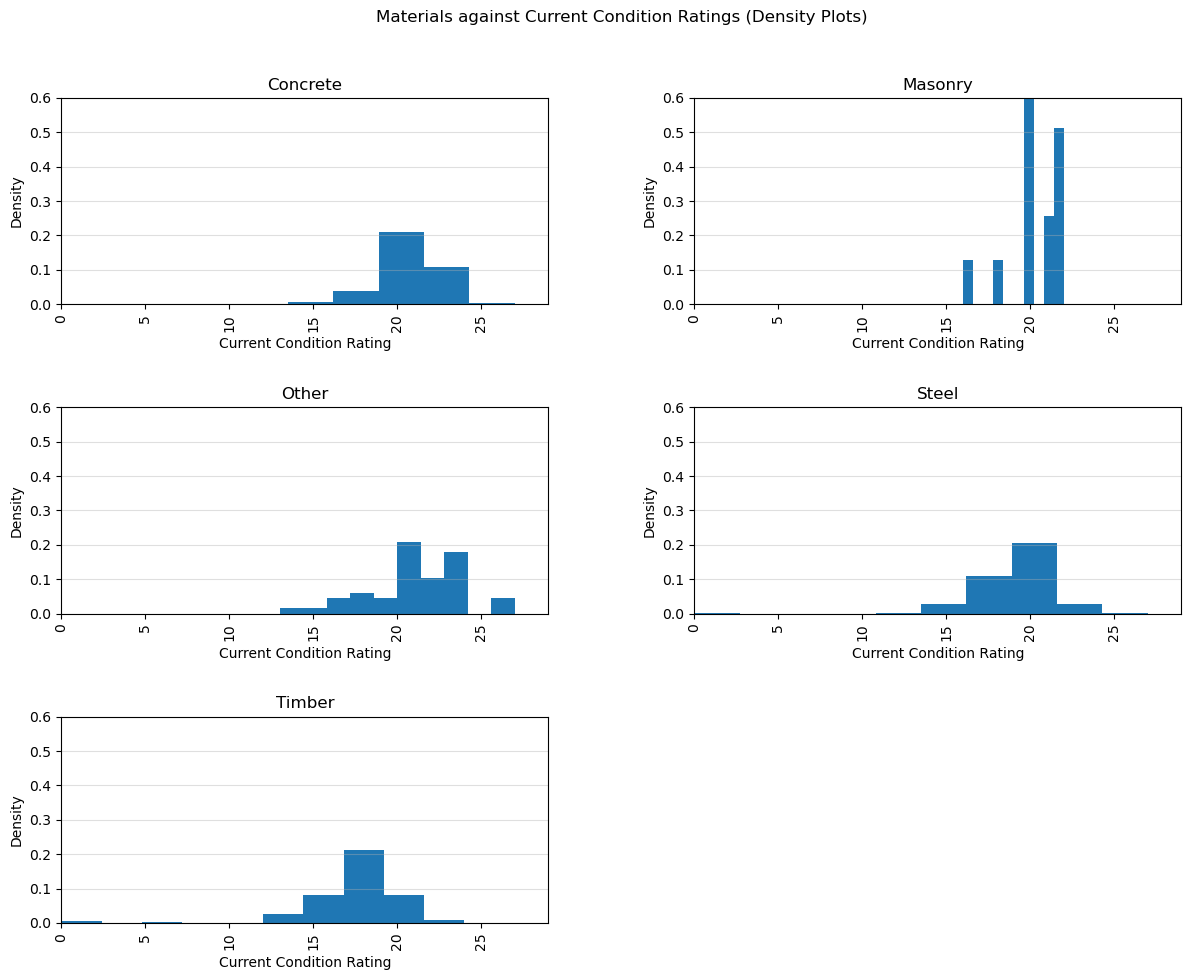

In [7]:
mat_hist = bridges.hist(column=['Current_Condition'], by=['Material'], figsize=(14,11), density=True, bins=10)
mat_hist_titles = ['Concrete', 'Masonry', 'Other', 'Steel', 'Timber', ' ']

for i, ax in enumerate(mat_hist.flatten()):
    ax.set_xlim(0, 29)
    ax.set_ylim(0, 0.6)
    ax.set_title(f'{mat_hist_titles[i]}')
    ax.set_xlabel('Current Condition Rating')
    ax.set_ylabel('Density')
    ax.grid(axis='y', alpha=0.4)
    ax.tick_params(labelbottom=True)
    ax.tick_params(labelleft=True)

plt.suptitle('Materials against Current Condition Ratings (Density Plots)')
plt.show()

C:\Users\samue\AppData\Local\Temp\ipykernel_33400\4187234949.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  design_hist = bridges.hist(column=['Current_Condition'], by=['Design'], figsize=(14,11), sharey=True, density=True, bins=10)


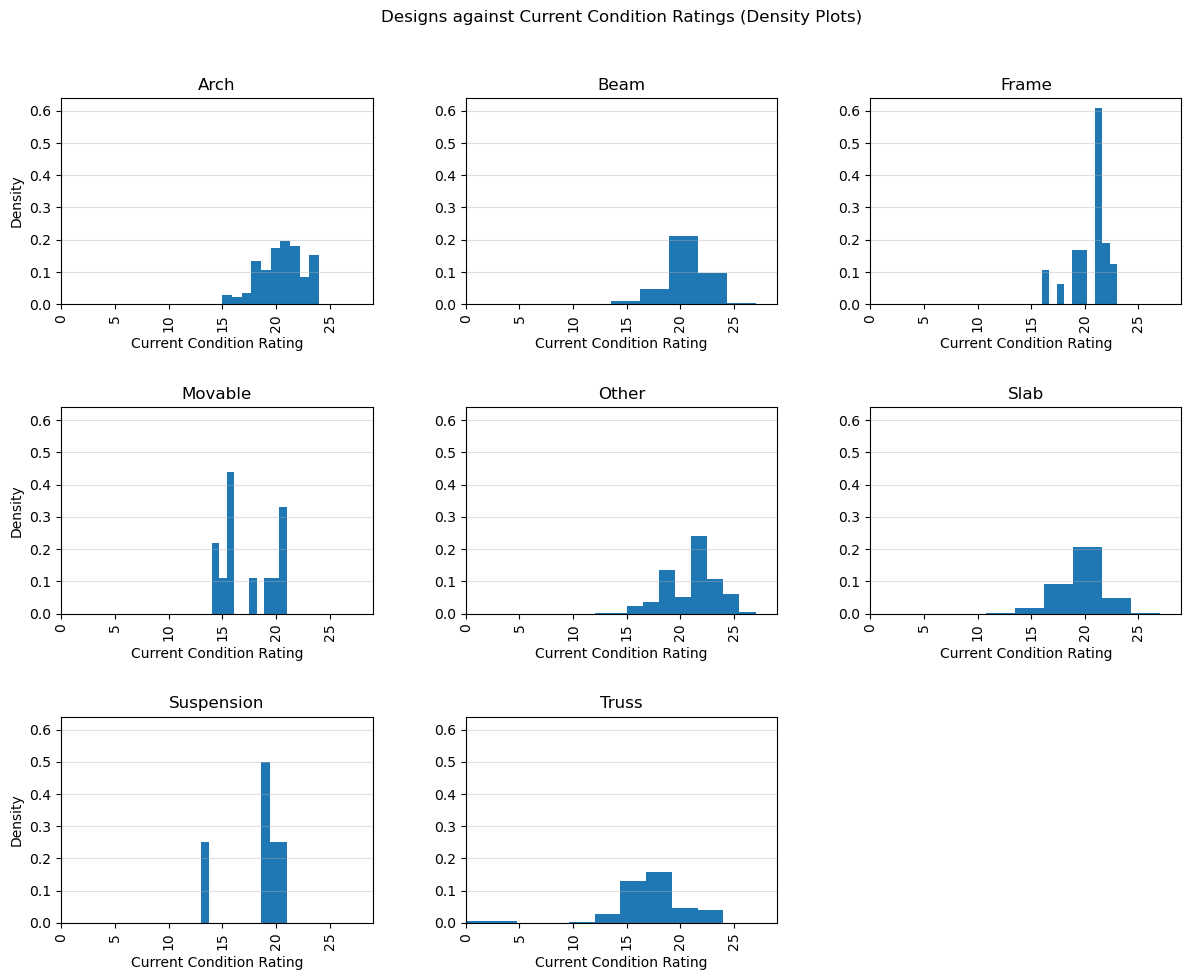

In [8]:
design_hist = bridges.hist(column=['Current_Condition'], by=['Design'], figsize=(14,11), sharey=True, density=True, bins=10)
design_hist_titles = ['Arch', 'Beam', 'Frame', 'Movable', 'Other', 'Slab', 'Suspension', 'Truss', '']

for i, ax in enumerate(design_hist.flatten()):
    ax.set_xlim(0, 29)
    ax.set_title(f'{design_hist_titles[i]}')
    ax.set_xlabel('Current Condition Rating')
    ax.set_ylabel('Density')
    ax.grid(axis='y', alpha=0.4)
    ax.tick_params(labelbottom=True)
    ax.tick_params(labelleft=True)

plt.suptitle('Designs against Current Condition Ratings (Density Plots)')
plt.show()

The Materials against Current Condition Ratings density plots were used alongside the counts to determine category consolidation.

It’s evident that most materials peak around 20, with Timber peaking below this and generally performing the worst with a visible tail reaching the lowest bin. Although Timber represents a lower proportion of bridges overall, these lower scores should be preserved in our model. 

The distribution for Masonry is similar to the others even though it has far fewer samples than the rest, given its lower sample size and distribution similarity to the Other category it has been consolidated into Other to prevent noise in the regression model. 

A similar approach has been taken with the design categories, with Arch and Truss being consolidated into the Other category due to having low counts and non-unique distributions. 

Suspension, Frame and Movable on the other hand have not been consolidated on account of their distributions which appear to show unique characteristics. Suspension and Movable both appear bimodal with a prevalent Fair group and Poor/Failing group, while Frame reports higher than the average score distribution. As such these will be kept for the regression model as their unique characteristic could be beneficial for model accuracy.

In [9]:
mat_dict = { 'Concrete': 'Concrete', 'Masonry': 'Other',
            'Other': 'Other', 'Steel': 'Steel', 'Timber': 'Timber'}

des_dict = {'Arch': 'Other', 'Beam': 'Beam', 'Frame': 'Frame', 'Movable': 'Movable',
            'Other': 'Other', 'Slab': 'Slab', 'Suspension': 'Suspension', 'Truss': 'Other'
            }

def replace_mat(row):
    return mat_dict[row]

def replace_des(row):
    return des_dict[row]

bridges['Merged_Materials'] = bridges['Material'].apply(replace_mat)
bridges['Merged_Designs'] = bridges['Design'].apply(replace_des)

The distribution of Bridges by Age has been plotted below. It shows that most bridges fall within the 5 to 70 year age range, while also indicating that there is a drop in numbers of bridges to negligible figures past the age of 100 years. 

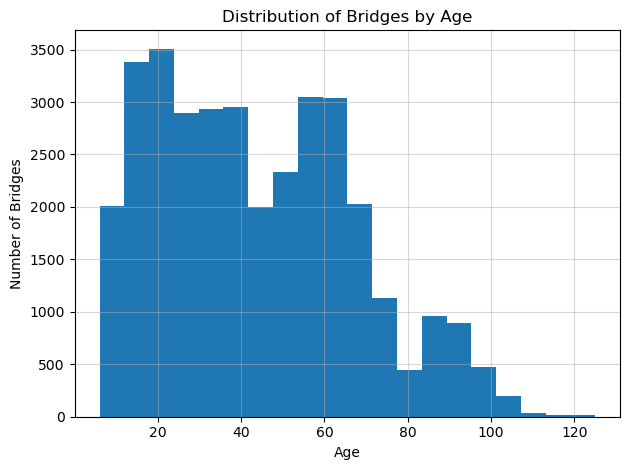

In [10]:
bridges['Age'].hist(bins=20)
plt.title('Distribution of Bridges by Age')
plt.xlabel('Age')
plt.ylabel('Number of Bridges')
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [11]:
old_bridges = bridges[bridges['Age'] > 100]
old_bridges['Historic'].value_counts()

Historic
Possible        243
Register         73
Not historic      0
Unknown           0
Name: count, dtype: int64

A sum count has been returned for Historic classifications for bridges over 100 years old and it’s noted that none of these are confirmed non-historic. Due to the different maintenance which may be required for these historic bridges and the small proportion of the sample which these bridges over the age of 100 make up, they have been removed from the regression model to benefit accuracy and remove potential bias.

In [12]:
bridges = bridges[bridges['Age'] <= 100]

## 3. Exploratory Analysis

In this section the relationship between the predictors and the target variable (Current Condition) will be investigated. The predictors will also be compared to each other and any preliminary conclusion will be discussed.

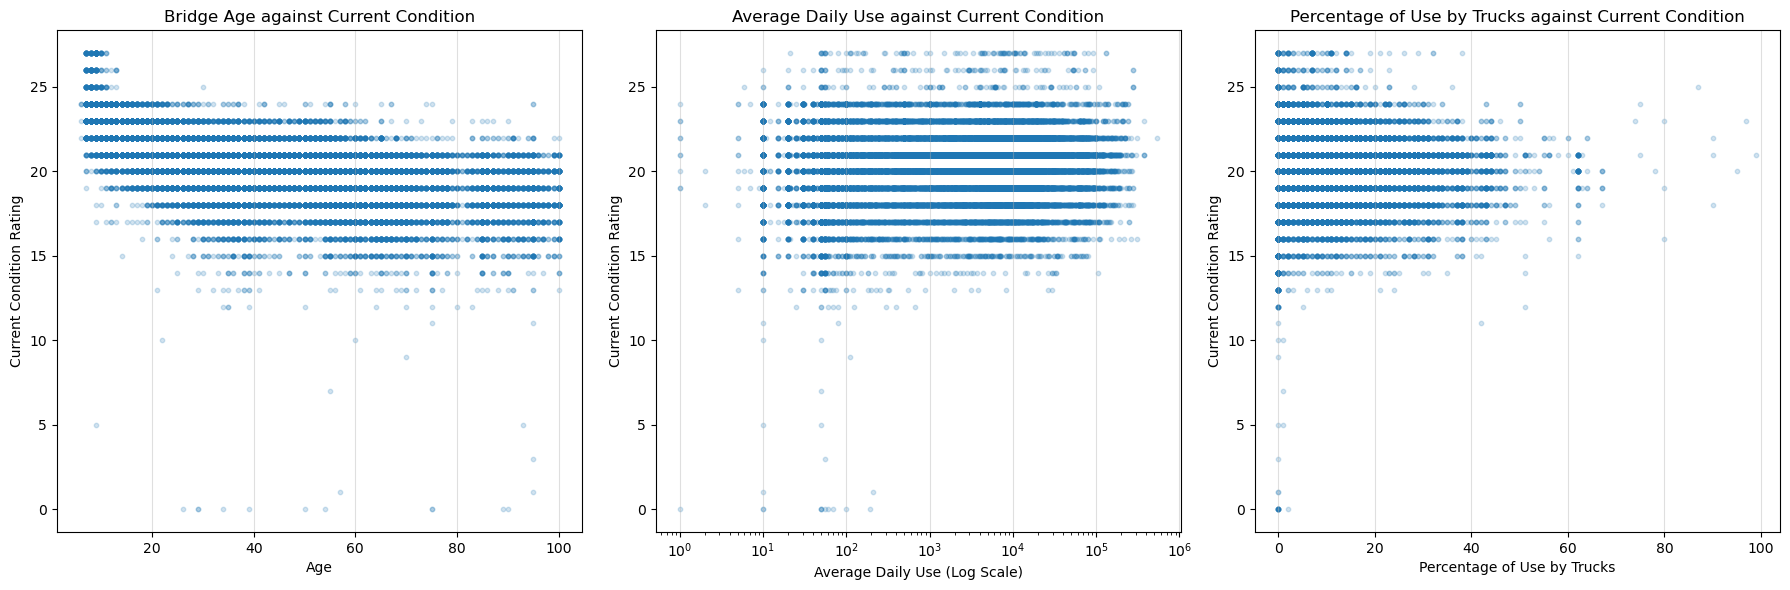

In [13]:
fig, axes = plt.subplots(nrows = 1, ncols= 3, figsize=(18,6))

axes[0].scatter(bridges['Age'], bridges['Current_Condition'], alpha = 0.2, s=10)
axes[0].set_title('Bridge Age against Current Condition')
axes[0].set_ylabel('Current Condition Rating')
axes[0].set_xlabel('Age')
axes[0].grid(axis='x', alpha=0.4)

axes[1].scatter(bridges['AverageDaily'], bridges['Current_Condition'], alpha = 0.2, s=10)
axes[1].set_title('Average Daily Use against Current Condition')
axes[1].set_ylabel('Current Condition Rating')
axes[1].set_xlabel('Average Daily Use (Log Scale)')
axes[1].set_xscale('log')
axes[1].grid(axis='x', alpha=0.4)

axes[2].scatter(bridges['Trucks_percent'], bridges['Current_Condition'], alpha = 0.2, s=10)
axes[2].set_title('Percentage of Use by Trucks against Current Condition')
axes[2].set_ylabel('Current Condition Rating')
axes[2].set_xlabel('Percentage of Use by Trucks')
axes[2].grid(axis='x', alpha=0.4)

plt.tight_layout()

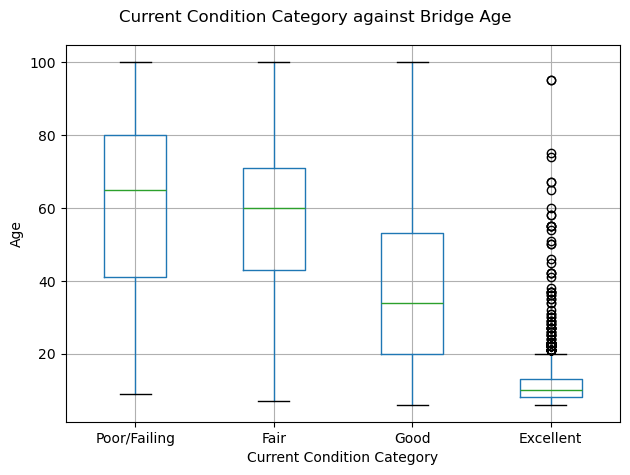

In [14]:
age_boxplot = bridges.boxplot(column='Age', by='Current_Condition_Category')

age_boxplot.set_title('')
plt.suptitle('Current Condition Category against Bridge Age')
age_boxplot.set_xlabel('Current Condition Category')
age_boxplot.set_ylabel('Age')
plt.tight_layout()

The relationship between the three continuous predictor variables and the target is shown in the above scatter plots. 

There appears to be moderate negative correlation between Bridge Age and Current Condition Rating, implying a relationship in which as bridges become older, their condition decreases. The centre and right plots do not show a linear relationship, this suggests that Average Daily Use and Percentage of use by Trucks will have a negligible effect on the regression model.

The boxplot strongly supports the relationship between Age and Current Condition, with the median score reducing as age increases. It’s also apparent that almost all of the Excellent condition bridges have been built in the last twenty years.

The below boxplots visualise the relationship between the two categorical variables and the target variable. Of the materials it appears Timber has the lowest median score and largest spread towards lower ratings, whereas Concrete and Other have the highest. Moveable is the design with the lowest score however it does make up a low proportion of samples. The frame design has a high median with a small interquartile range suggesting consistently high condition scores, behaviour which was previously noted in the histograms in Part 1.

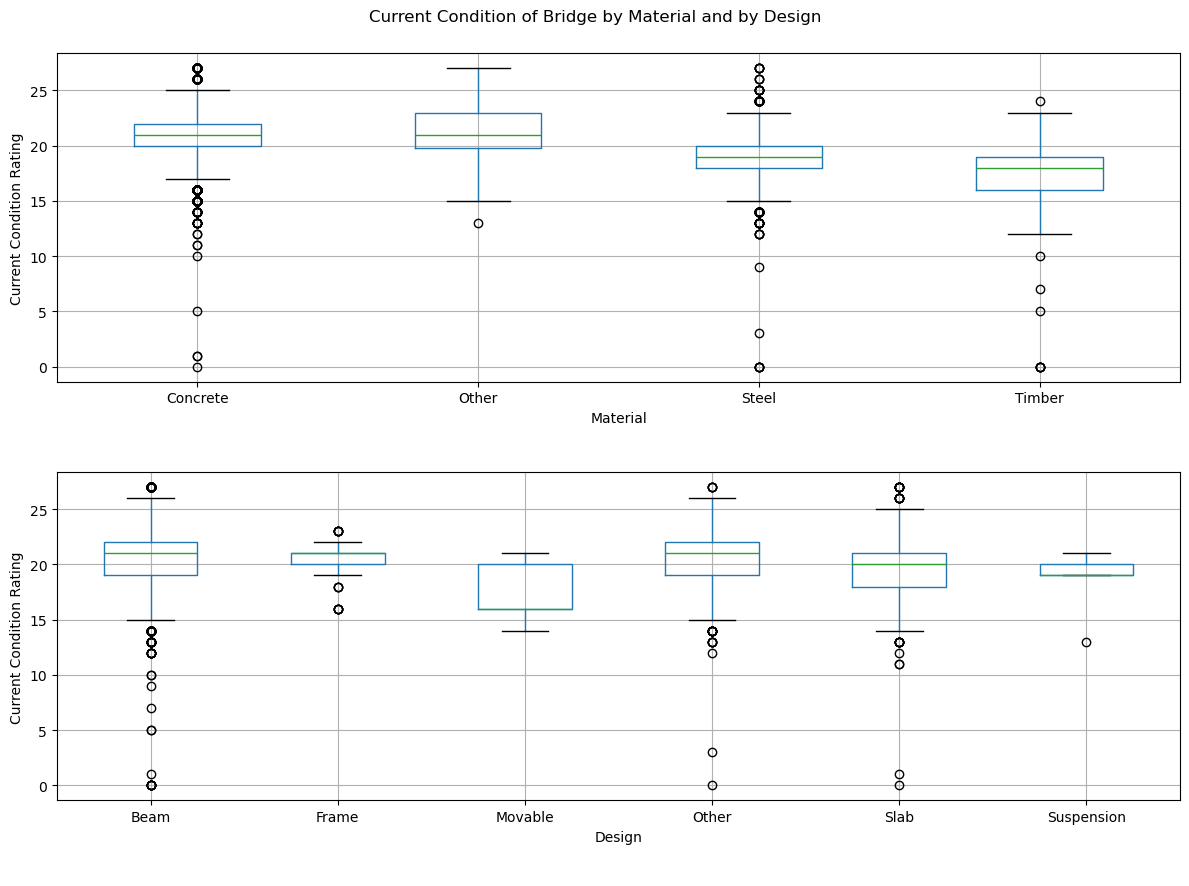

In [15]:
fig, (a1, a2) = plt.subplots(2,1, figsize=(12,9))

bridges.boxplot(column='Current_Condition', by='Merged_Materials', ax=a1)
bridges.boxplot(column='Current_Condition', by='Merged_Designs', ax=a2)

fig.suptitle('Current Condition of Bridge by Material and by Design\n')
a1.set_title('')
a2.set_title('')

a1.set_xlabel('Material\n\n')
a1.set_ylabel('Current Condition Rating')
a2.set_xlabel('Design\n\n')
a2.set_ylabel('Current Condition Rating')

plt.tight_layout()

In the next section we look to quantify the relationships between the predictor variables. The continuous variables are cast onto a correlation matrix and a heatmap in order to view the strengths of their relationship and assess for collinearity. Cross-tabulations are used to compare the categorical variables and the target, Current Condition Category, this helps us understand the influence the categories have on the target as well as collinearity between the categorical predictors.

,Age,AverageDaily,Trucks_percent,Current_Condition
Age,1.000000,-0.051582,0.230023,-0.590710
AverageDaily,-0.051582,1.000000,0.022426,0.034279
Trucks_percent,0.230023,0.022426,1.000000,-0.049050
Current_Condition,-0.590710,0.034279,-0.049050,1.000000


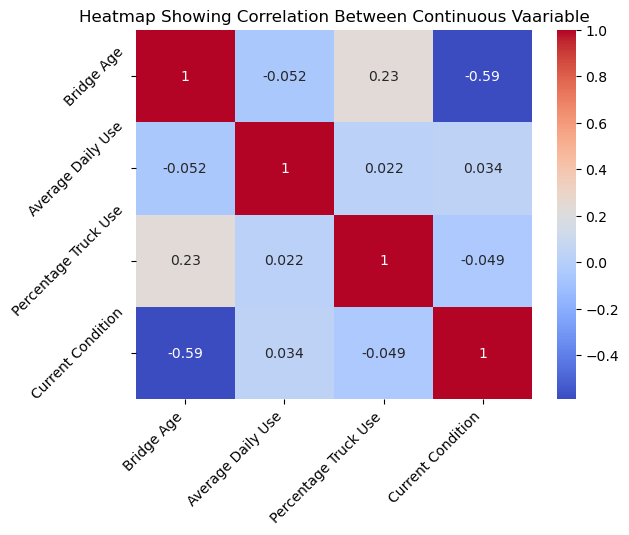

In [16]:
corr_matrix = bridges[['Age', 'AverageDaily', 'Trucks_percent', 'Current_Condition']].corr()
corr_heat = sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm')
corr_heat.set_title('Heatmap Showing Correlation Between Continuous Vaariable')
axis_labels = ['Bridge Age', 'Average Daily Use', 'Percentage Truck Use', 'Current Condition']
corr_heat.set_xticklabels(axis_labels, rotation=45, ha='right')
corr_heat.set_yticklabels(axis_labels, rotation=45)
corr_matrix

In [17]:
mat_cond_crosstab = pd.crosstab(bridges['Merged_Materials'], bridges['Current_Condition_Category'], normalize='index')
des_cond_crosstab = pd.crosstab(bridges['Merged_Designs'], bridges['Current_Condition_Category'], normalize='index')
mat_des_crosstab = pd.crosstab(bridges['Merged_Materials'], bridges['Merged_Designs'], normalize='index')
mat_cond_crosstab

Current_Condition_Category,Poor/Failing,Fair,Good,Excellent
Merged_Materials,,,,
Concrete,0.001525,0.224565,0.727391,0.046519
Other,0.017857,0.232143,0.607143,0.142857
Steel,0.011286,0.586396,0.393168,0.009151
Timber,0.079570,0.707527,0.210753,0.002151


In [18]:
des_cond_crosstab

Current_Condition_Category,Poor/Failing,Fair,Good,Excellent
Merged_Designs,,,,
Beam,0.003900,0.282848,0.676877,0.036375
Frame,0.000000,0.235294,0.764706,0.000000
Movable,0.153846,0.538462,0.307692,0.000000
Other,0.012987,0.308954,0.575530,0.102529
Slab,0.004982,0.420166,0.540688,0.034164
Suspension,0.200000,0.400000,0.400000,0.000000


In [19]:
mat_des_crosstab

Merged_Designs,Beam,Frame,Movable,Other,Slab,Suspension
Merged_Materials,,,,,,
Concrete,0.804068,0.002529,0.000000,0.036665,0.156738,0.000000
Other,0.000000,0.000000,0.017857,0.982143,0.000000,0.000000
Steel,0.933201,0.000000,0.001830,0.064359,0.000000,0.000610
Timber,0.997849,0.000000,0.000000,0.000000,0.000000,0.002151


The heatmap shows the highest correlation between age and current condition, as we had hypothesised, with a correlation coefficient of -0.59. A positive correlation of 0.23 is noted between Bridge Age and Percentage indicating collinearity, given it’s not too high we can allow Percentage Truck Use to stay in the regression model, if it were higher then it would risk negatively affecting our regression estimates. Correlation between the other continuous variables is negligible, confirming our previous hypothesis when reviewing the scatter plots.

The cross-tabulations reinforce the relationship between Timber and poor performance, having the highest proportion of Poor/Failing and Fair condition bridges with 7.95% falling into this category, concrete appears to have the lowest in Poor/Failing condition with 0.15%. Other materials also appear to have the highest proportion of Excellent ratings while Concrete has the most Good, and Timber has the most Fair, Steel doesn’t appear to dominate any category but has its highest proportion rated Fair. 

The multimodal behaviour of the Suspension and Movable designs is shown again on the Design cross-tabulation alongside their high proportions in the Poor/Failing Category (20% and 15.38% respectively), alongside Frame’s high proportion of Good rated bridges at 76%. The Beam design category, of which it is most numerous, is placed mostly within the Fair and Good categories and is likely the most reliable/cost effective given its numerosity and decent conditions. The Material/Design table shows that Beam is by far the most popular design for all material types, with Timber being almost 99.78% beam and Steel being 93.32%. This is however not the case for Other, which also favours the Other category of design. 

Given the high correlation Age has to the Current Condition Score, it’s been rendered below against each Material and Design category in the form of a Kernel Density Estimation plot, with the space under each line representing the proportional likelihood of that category being the age shown on the X-axis. Given the large difference in sample sizes, each line has been normalised so that the entire area under each equals 1.

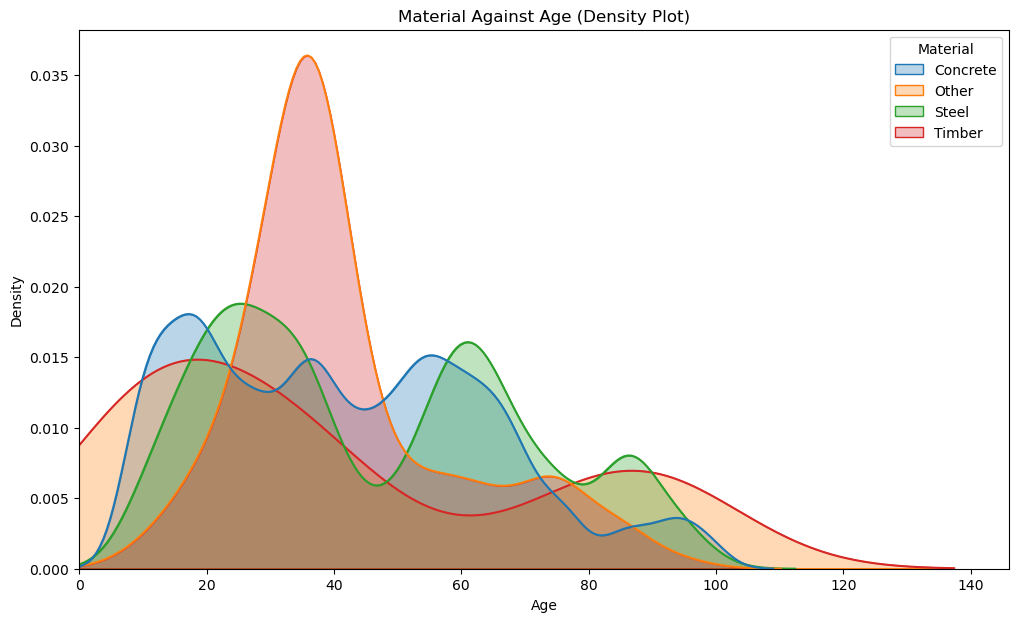

In [20]:
grouped_materials = bridges.groupby('Merged_Materials')

kde_concrete = grouped_materials.get_group('Concrete')
kde_other = grouped_materials.get_group('Other')
kde_steel = grouped_materials.get_group('Steel')
kde_timber = grouped_materials.get_group('Timber')

fig, ax1 = plt.subplots(1, 1, figsize=(12,7))
sns.kdeplot(data=bridges, x='Age', hue='Merged_Materials', common_norm=False)


sns.kdeplot(data=kde_concrete['Age'], label='Concrete', ax=ax1, alpha=0.3, fill=True)
sns.kdeplot(data=kde_other['Age'], label='Other', ax=ax1, alpha=0.3, fill=True)
sns.kdeplot(data=kde_steel['Age'], label='Steel', ax=ax1, alpha=0.3, fill=True)
sns.kdeplot(data=kde_timber['Age'], label='Timber', ax=ax1, alpha=0.3, fill=True)

ax1.legend(title='Material')
ax1.set_title('Material Against Age (Density Plot)')
plt.xlim(0,None)
plt.show()

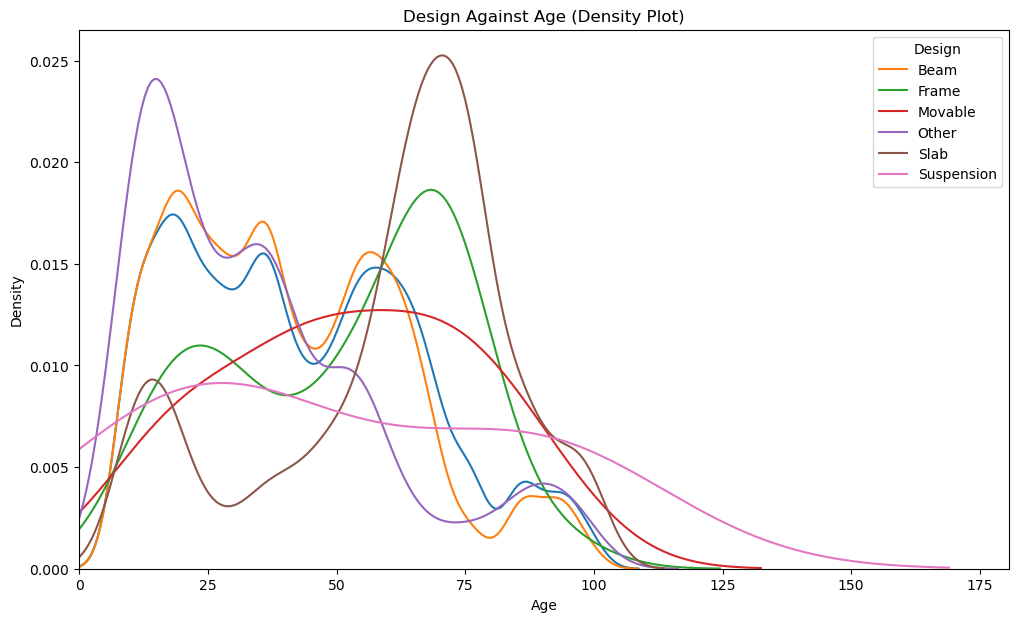

In [21]:
grouped_designs = bridges.groupby('Merged_Designs')

kde_beam = grouped_designs.get_group('Beam')
kde_frame = grouped_designs.get_group('Frame')
kde_movable = grouped_designs.get_group('Movable')
kde_other = grouped_designs.get_group('Other')
kde_slab = grouped_designs.get_group('Slab')
kde_suspension = grouped_designs.get_group('Suspension')

fig, ax1 = plt.subplots(1, 1, figsize=(12,7))
sns.kdeplot(data=bridges, x='Age', common_norm=False)


sns.kdeplot(data=kde_beam['Age'], label='Beam', ax=ax1, fill=False)
sns.kdeplot(data=kde_frame['Age'], label='Frame', ax=ax1, fill=False)
sns.kdeplot(data=kde_movable['Age'], label='Movable', ax=ax1, fill=False)
sns.kdeplot(data=kde_other['Age'], label='Other', ax=ax1, fill=False)
sns.kdeplot(data=kde_slab['Age'], label='Slab', ax=ax1, fill=False)
sns.kdeplot(data=kde_suspension['Age'], label='Suspension', ax=ax1, fill=False)

ax1.legend(title='Design')
ax1.set_title('Design Against Age (Density Plot)')
plt.xlim(0,None)
plt.show()

It’s evident from the Materials plots above that bridges from the Other categories were most popular between twenty and fifty years ago. It appears less bridges are being built across all categories apart from Timber over the last twenty years. Steel has an interesting shape, showing a large increase in production post war followed by a significant drop in the 1970s. This could be related to the American post war steel boom which went on to suffer in the latter quarter of the 20th century as international competition recovered. It’s also interesting that Concrete production slowed and recovered in a similar pattern to Steel around the 1970’s, they both may have been influenced by the 1973 recession, with the rise in Other, possibly cheaper alternatives around this timing being a direct result of less investment in infrastructure projects.

The Design plot shows a similar shape to Materials, with the rate of bridges being built increasing until the 1970s, at which point production decreases and Other designs begin to make an appearance. The Slab design seems to have peaked in popularity around the 1940s with a small resurgence in the last twenty years. Although Suspension appears the most consistent, and Movable appears to buck the trend of the rest, it must be remembered that their sample sizes are very small. 

The main trend noted here is the overall decrease in bridges being built in the last twenty years. It's not evident from the data why exactly, whether this is a data error, a lack of investment or even a lack of need. With the American interstate highway project reaching its apex between the 1960s and 1990s, it’s possible the need for new bridges has dramatically reduced.


### Initial Findings 

At this point with regard to the questions raised by the client, preliminarily we can say that age is likely going to be the most influential condition, with the Timber category being linked to a higher chance of poor condition. While the frame design suggest a bridge will be of better quality, its small sample indicates this should be taken with caution. The small sample size can introduce random variability to our model and reduce the reliability of its coefficient. We can also presume at this point that Average Daily Use and Percentage of Trucks will not have much or even any effect on the target variable. 

The lack of correlation between the Average Daily Use and Percentage of Trucks variables and the target variable indicates we may be relying on three of our five predictors to do the heavy lifting on the regression, leaving us with a moderate to low accuracy on our final model.


## 4. Regression Modeling

Now the data has been cleaned and initially analysed, the regression model will be fitted and suitability assessed.

The other categories are mixes of low frequency and unknown materials and designs. Therefore they have been removed from the modeling process, as the heterogeneity of these categories will force the coefficients to represent multiple states, thus introducing noise and lowering accuracy.

In [22]:
#Filtering out other categories
model_parameters = bridges[(bridges['Merged_Materials'] != 'Other') & (bridges['Merged_Designs'] != 'Other')]

#Reference encoding categorical variables
material_d = pd.get_dummies(model_parameters['Merged_Materials'], drop_first=True)
design_d = pd.get_dummies(model_parameters['Merged_Designs'], drop_first=True)

#Setting predicitors and labels
X = np.column_stack((model_parameters['Age'], model_parameters['AverageDaily'], model_parameters['Trucks_percent'], material_d, design_d))
y = model_parameters['Current_Condition']

#Fitting linear regression model
reg = LinearRegression().fit(X, y)

#Obtaining key metrics
R2 = reg.score(X, y)
y_hat = reg.predict(X)
RMSE = mean_squared_error(y, y_hat) 

print('The R^2 value for the regression is:', round(R2, 2))
print('The Root of the Mean Squared value for the regression is:', round(RMSE, 2))

The R^2 value for the regression is: 0.45
The Root of the Mean Squared value for the regression is: 2.11


After applying regression to the predictors, the $R^2$ and Root of the Mean Squared Error (RMSE) values have been returned. These are both metrics which can be used to assess the suitability of the regression model.

The $R^2$ metric returns the proportion of the variance of the target variable correctly predicted by our predictors, ranging from 0 to 1 with 0 indicating it predicts none of the variation and 1 indicating it predicts all variation. The value of 0.45 suggests moderate prediction capabilities, especially given the low number of predictor variables, and the low correlation of Average Daily Use and Percentage of Trucks found during the exploratory analysis.

The RMSE calculates the average distance between the actual target and predicted targets. Our RMSE of 2.11 indicates that on average our model can predict the current condition of a bridge within 2.11 points on our 27 point Current Condition scale.

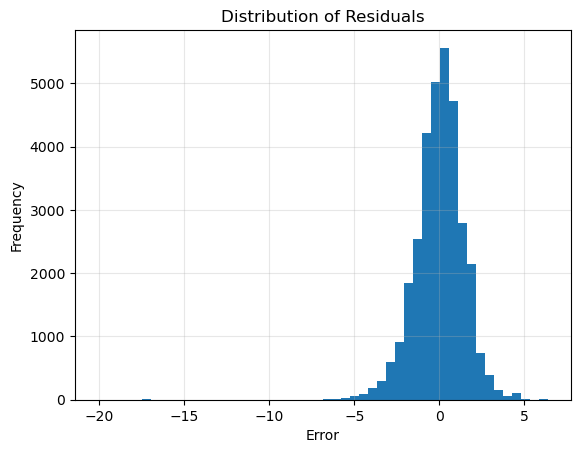

In [23]:
residuals = y-y_hat
plt.hist(residuals, bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()


The residual errors have been calculated by subtracting the predicted target values from the actual target values, their distribution has been plotted above. A normally distributed residual distribution would suggest a well fit model, as its errors would be equal in both directions reflecting the best fit line. The plot above shows our residuals to be mostly normally distributed around zero, however with a long tail stretching to around -20. This implies that the model has a tendency to over predict the very low rated bridges.

In [24]:
#Returning coefficients from regression
reg_age, reg_av_daily, reg_trucks, reg_steel, reg_timber, reg_frame, reg_movable, reg_slab, reg_suspension = reg.coef_

#Standardising predictor data, running regression and returning coefficients
Z = StandardScaler().fit_transform(X)
z_reg = LinearRegression().fit(Z, y)
beta_age, beta_av_daily, beta_trucks, beta_steel, beta_timber, beta_frame, beta_movable, beta_slab, beta_suspension = z_reg.coef_

#Creating a coefficeient table and displaying
coeff_labels = ['Bridge Age', 'Average Daily Use', 'Trucks Percentage', 'Steel', 'Timber', 'Frame', 'Movable', 'Slab', 'Suspension']
reg_coeff = [reg_age, reg_av_daily, reg_trucks, reg_steel, reg_timber, reg_frame, reg_movable, reg_slab, reg_suspension]
z_reg_coeff = [beta_age, beta_av_daily, beta_trucks, beta_steel, beta_timber, beta_frame, beta_movable, beta_slab, beta_suspension]

coeff_table = pd.DataFrame([coeff_labels, reg_coeff, z_reg_coeff]).T

coeff_table = coeff_table.rename(columns={
    0:'Predictor Variable',
    1:'Coefficient',
    2:'Standardised Coefficient'
})

coeff_table

,Predictor Variable,Coefficient,Standardised Coefficient
0,Bridge Age,-0.048796,-1.128153
1,Average Daily Use,-0.000001,-0.018924
2,Trucks Percentage,0.004848,0.050499
3,Steel,-1.309566,-0.51243
4,Timber,-3.176115,-0.377148
5,Frame,0.283859,0.012969
6,Movable,-1.258777,-0.024181
7,Slab,-0.071022,-0.023859
8,Suspension,-0.172111,-0.002134


The above table displays the ideal coefficients calculated for our linear regression. These have been standardised to allow direct comparison between them. Confirming our assumptions made earlier, Bridge Age does have the most weight when predicting based on the predictor variables ,with a strong negative correlation confirming that as a bridge gets older it is more likely to have a lower condition score. It is followed by Steel and then Timber, which both also suggest that falling into one of these categories will return a bridge with a lower condition score. The other predictors contribute a negligible effect.

We can see from the non-standardised coefficients that for every year a bridge increases in age, it will be expected that the condition score will drop 0.049.

The Current Condition Scores have been plotted against the Predicted Current Condition Scores below, as has the effect size of each variable upon the current condition score.


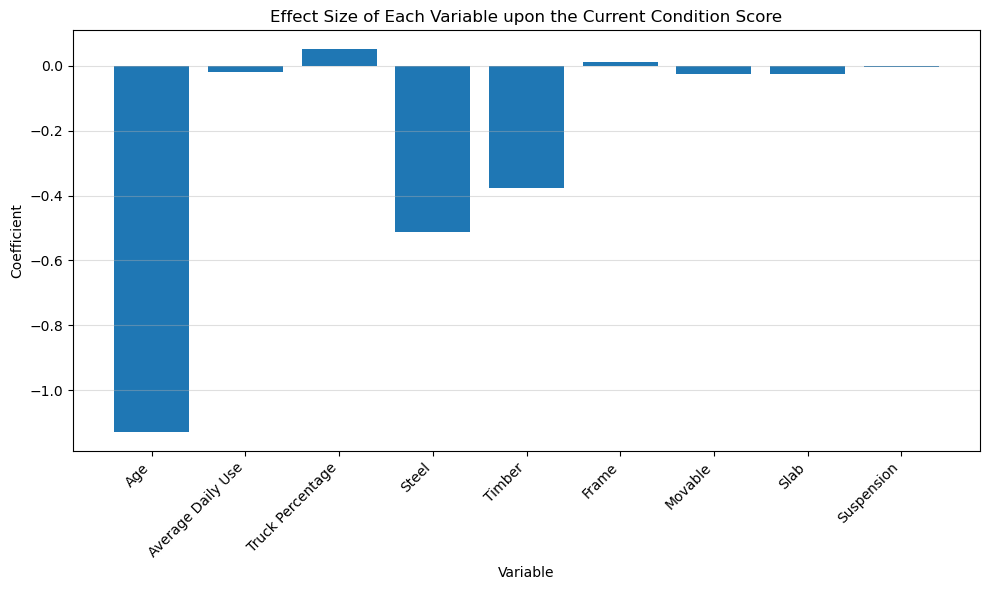

In [25]:
coef_headers = ['Age', 'Average Daily Use', 'Truck Percentage', 'Steel', 'Timber', 'Frame', 'Movable', 'Slab', 'Suspension']
coeffs = [beta_age, beta_av_daily, beta_trucks, beta_steel, beta_timber, beta_frame, beta_movable, beta_slab, beta_suspension]
coeff_table = pd.DataFrame({'Variable': coef_headers, 'Coefficient': coeffs})

plt.figure(figsize=(10,6))
plt.bar(coeff_table['Variable'], coeff_table['Coefficient'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Variable')
plt.ylabel('Coefficient')
plt.grid(axis='y', alpha=0.4)
plt.title('Effect Size of Each Variable upon the Current Condition Score')
plt.tight_layout()

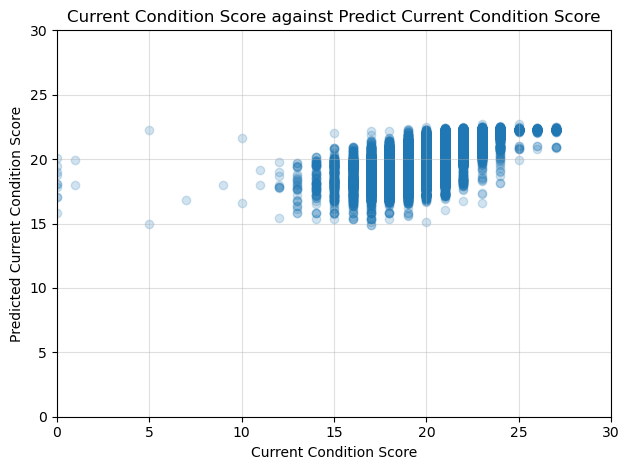

In [26]:
plt.scatter(y, y_hat, alpha=0.2)
plt.xlim(0, 30)
plt.ylim(0,30)
plt.xlabel('Current Condition Score')
plt.ylabel('Predicted Current Condition Score')
plt.title('Current Condition Score against Predict Current Condition Score')
plt.grid(alpha=0.4)
plt.tight_layout()

## 5. Conclusion

It’s clear that some predictor variables have more influence than others, this is visualised in the bar chat above. We’ve mentioned previously that Age, Steel and Timber have the most influence whereas Average Daily Use and Percentage of Trucks are mostly negligible. The above plot allows us to view the magnitude of this relationship.

The ideal shape of the scatter plot above would be a diagonal line from the bottom left up, this would imply every condition score was perfectly predicted. Our model exhibits some moderate positive correlation, in line with our $R^2$ value suggesting that our variables can predict the target with a moderate degree of success. We can also clearly see the low scores being overpredicted as reflected in the residual distribution.

If further analysis were to be done I would suggest further outlier removal, alongside removal of the Average Daily Use and Percentage of Trucks predictors to keep our model simple given their effect are negligible. I would also recommend testing with a higher order polynomial that may be able to model our data better than a strictly linear relationship.
